# Texture Feature Correlation

In [1]:
import cv2
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

In [2]:
# Set LBP parameters (radius, n_points, and n_bins)
radius = 2  # Distance from center
n_points = 8 * radius  # Number of neighbor points
n_bins = n_points + 2  # numebr of bins

In [3]:
# Compute and normalize LBP histogram
def extract_lbp_features(image_path):
    """Extracts LBP histogram features from an image."""
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        return None  # Skip

    # Compute LBP
    lbp = local_binary_pattern(image, n_points, radius, method="uniform")
    
    # Compute LBP histogram
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(n_bins + 1), range=(0, n_bins))
    
    # Normalize histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    
    return hist

In [4]:
# Load dataset path
dataset_path = "crab-images-dataset/test"

In [5]:
# Dataset Preparation: Extract LBP features each species folder and store it in data[] for dataframe
data = []

# Loop through each species folder
for species in os.listdir(dataset_path):
    species_path = os.path.join(dataset_path, species)
    
    if os.path.isdir(species_path):
        for image_name in os.listdir(species_path):
            image_path = os.path.join(species_path, image_name)
            
            # Extract LBP features
            lbp_features = extract_lbp_features(image_path)
            
            if lbp_features is not None:
                data.append([species] + lbp_features.tolist())

In [6]:
# Convert to Dataframe
columns = ["Species"] + [f"LBP_Bin_{i}" for i in range(n_bins)]
df = pd.DataFrame(data, columns=columns)

In [7]:
# Compute average LBP features for each species
species_lbp_avg = df.groupby("Species").mean()

In [8]:
# Select two species for texture feature comparison
def cmpr_texture_feature_species(target, cmpr_species):
    # Get their average LBP features
    lbp_1 = species_lbp_avg.loc[target].values.reshape(1, -1)
    lbp_2 = species_lbp_avg.loc[cmpr_species].values.reshape(1, -1)

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(lbp_1.flatten())), lbp_1.flatten(), alpha=0.6, label=target, color='blue')
    plt.bar(range(len(lbp_2.flatten())), lbp_2.flatten(), alpha=0.6, label=cmpr_species, color='red')
    plt.xlabel("LBP Pattern Bins")
    plt.ylabel("Frequency")
    plt.title(f"LBP Feature Comparison: {target} vs {cmpr_species}")
    plt.legend()
    
    # Save the figure
    filename = f"plot_{target}_vs_{cmpr_species}.png"
    plt.savefig(filename)
    plt.show()

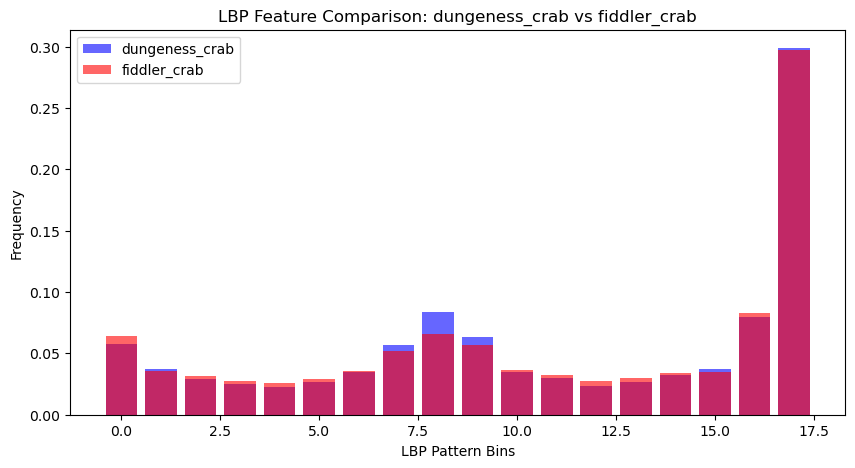

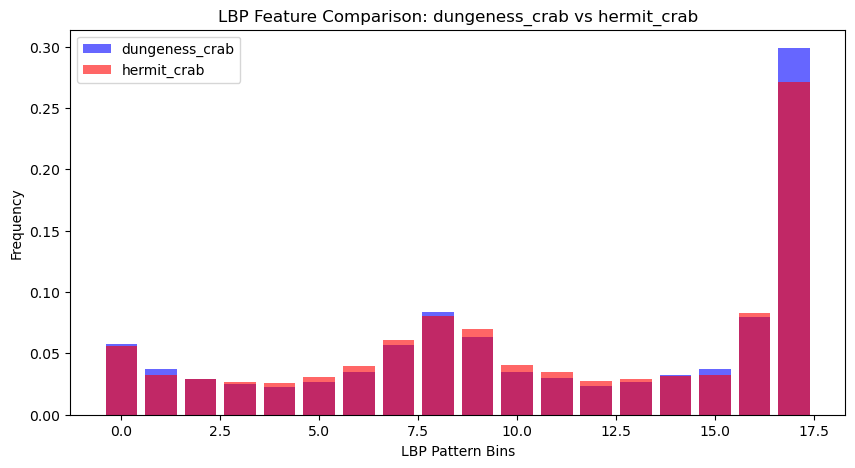

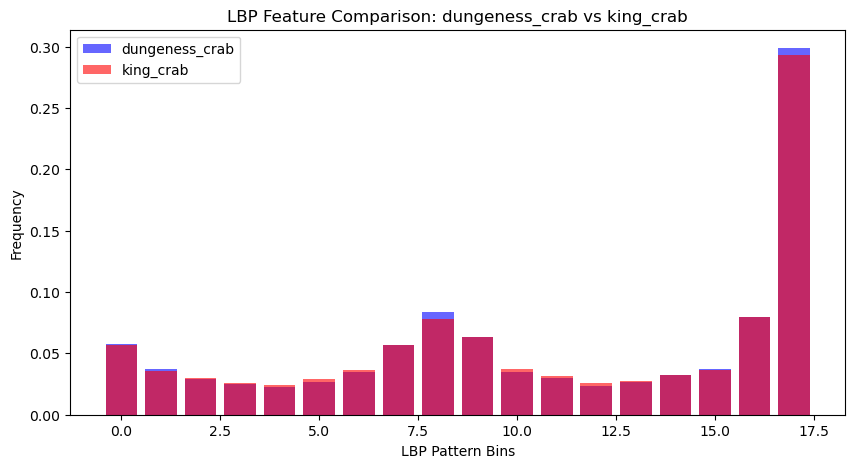

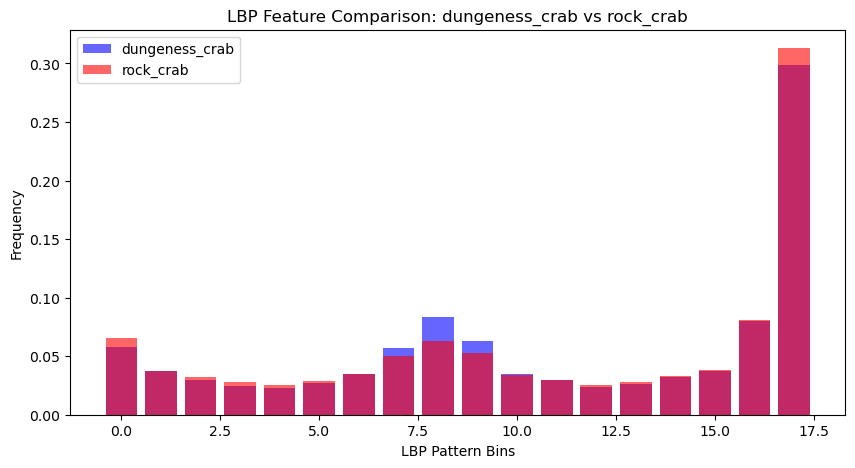

In [9]:
# Compare Dungeness Crab to other species
target = "dungeness_crab"
species_list = ["fiddler_crab", "hermit_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_texture_feature_species(target, species)

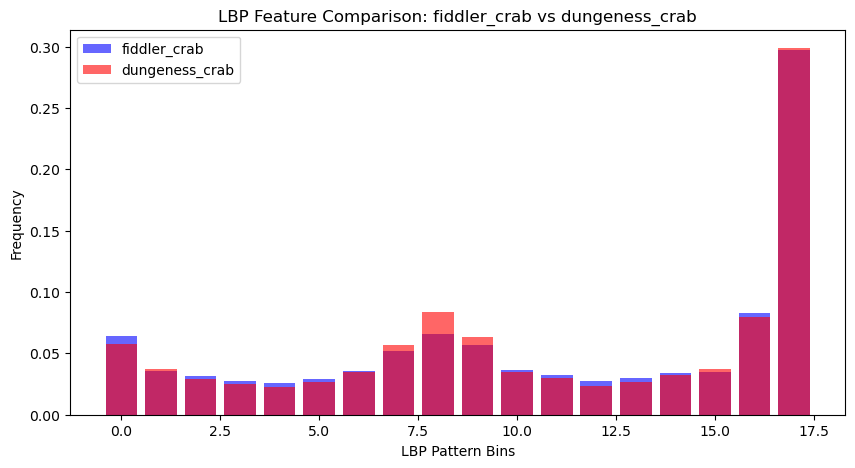

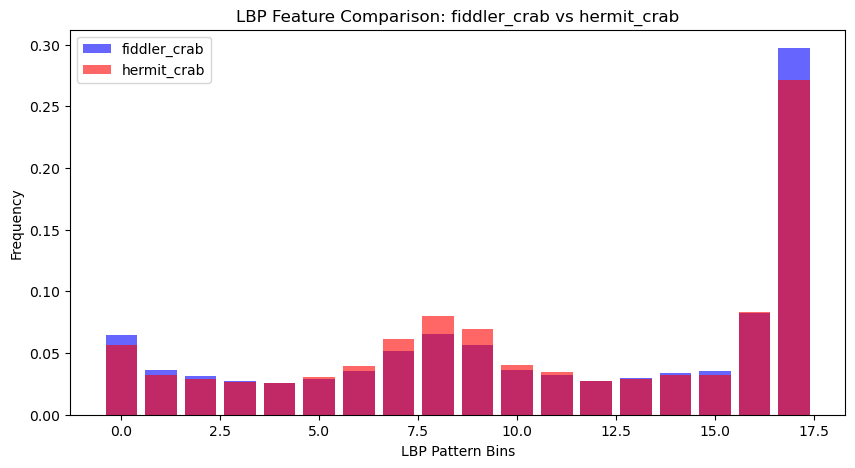

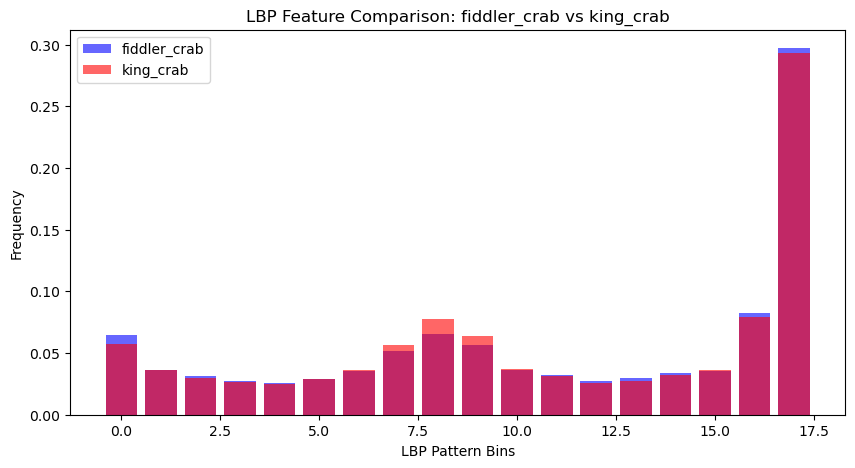

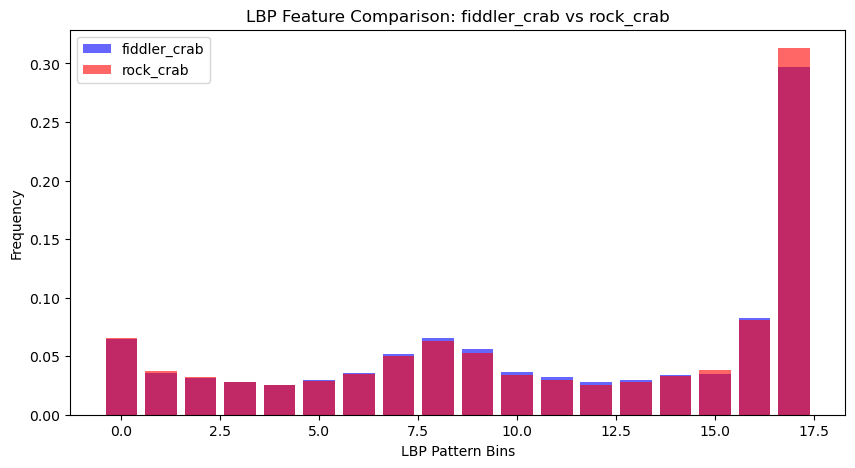

In [10]:
# Compare Fiddler Crab to other species
target =  "fiddler_crab"
species_list = ["dungeness_crab", "hermit_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_texture_feature_species(target, species)

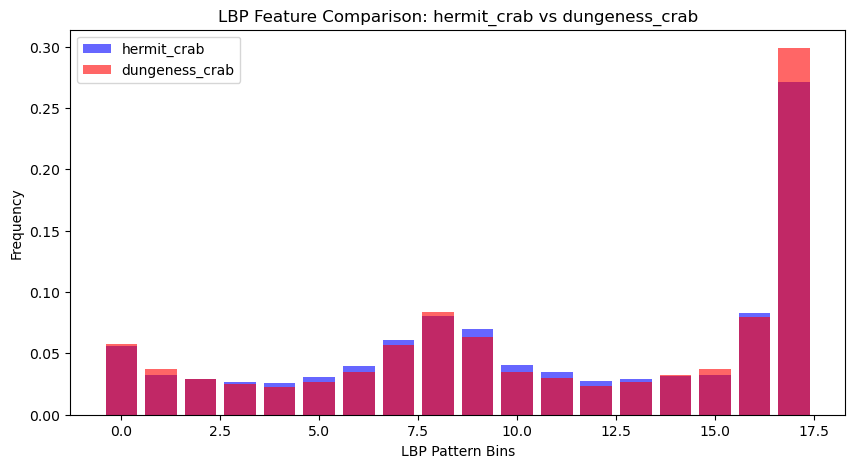

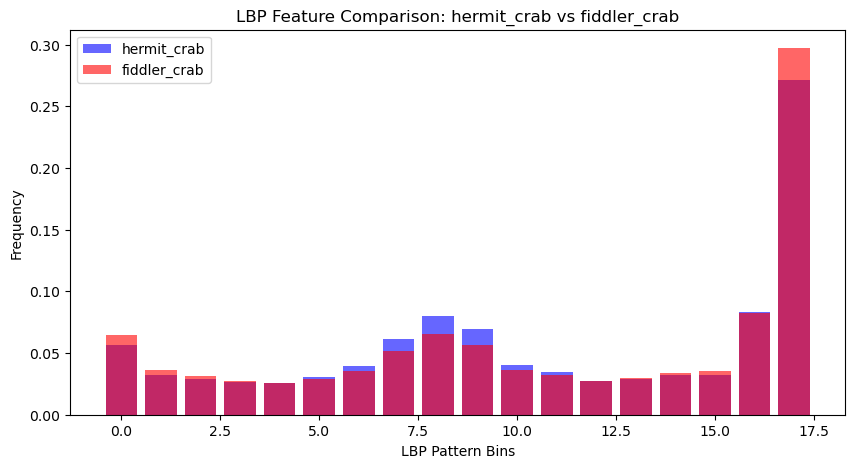

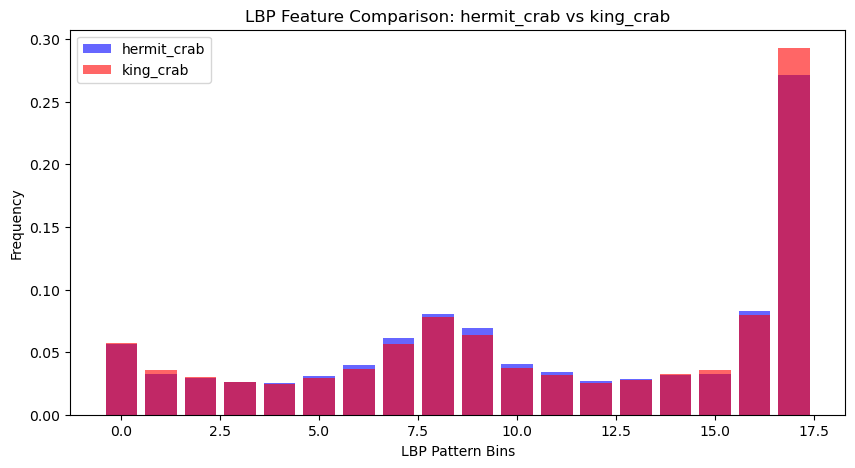

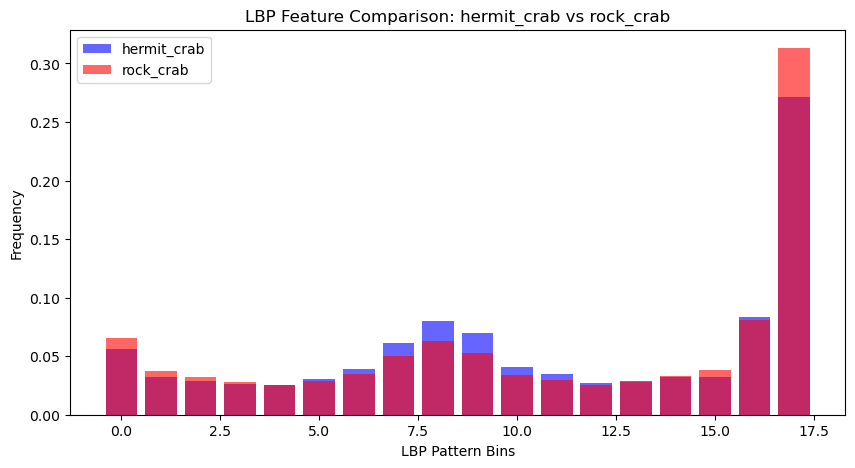

In [11]:
# Compare Hermit Crab to other species
target =  "hermit_crab"
species_list = ["dungeness_crab", "fiddler_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_texture_feature_species(target, species)

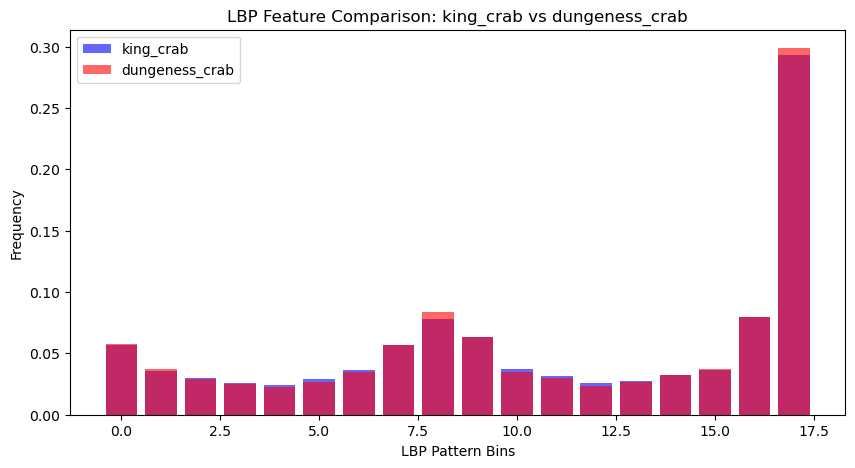

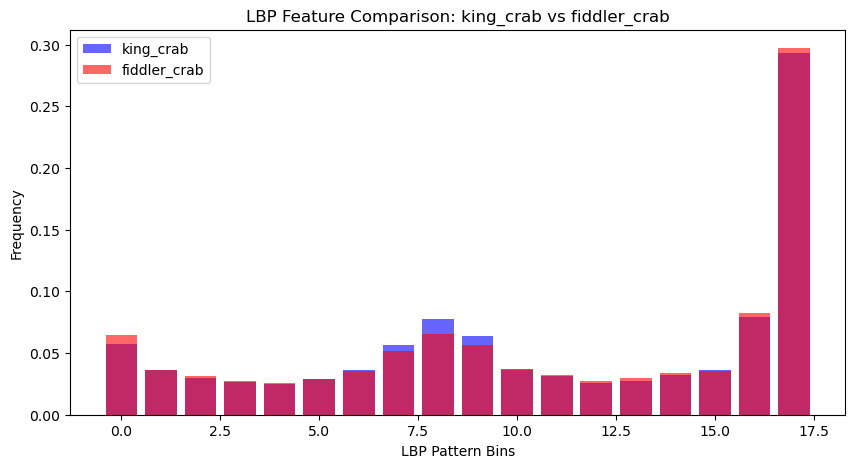

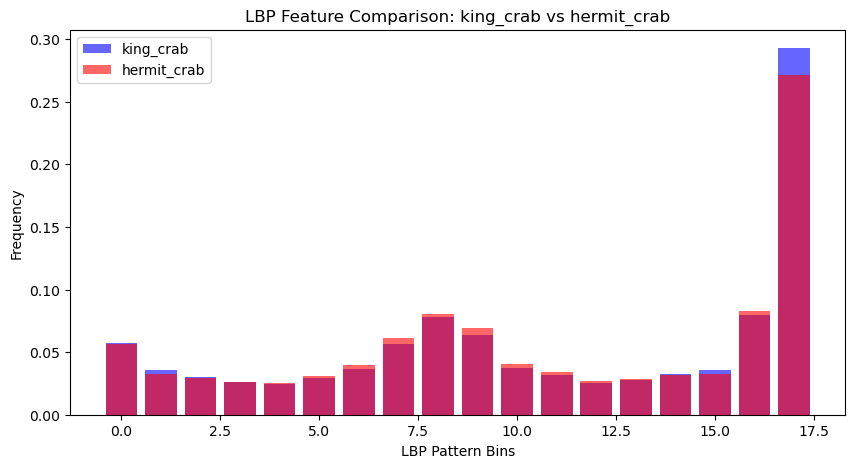

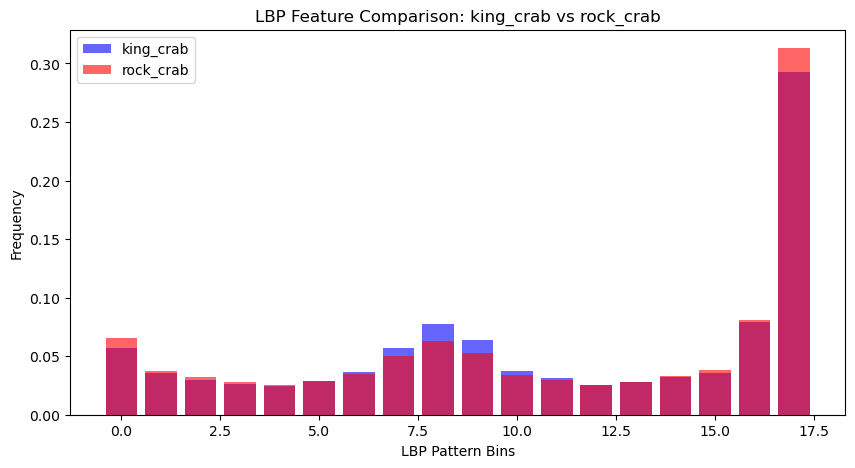

In [12]:
# Compare King Crab to other species
target =  "king_crab"
species_list = ["dungeness_crab", "fiddler_crab", "hermit_crab", "rock_crab"]

for species in species_list:
    cmpr_texture_feature_species(target, species)

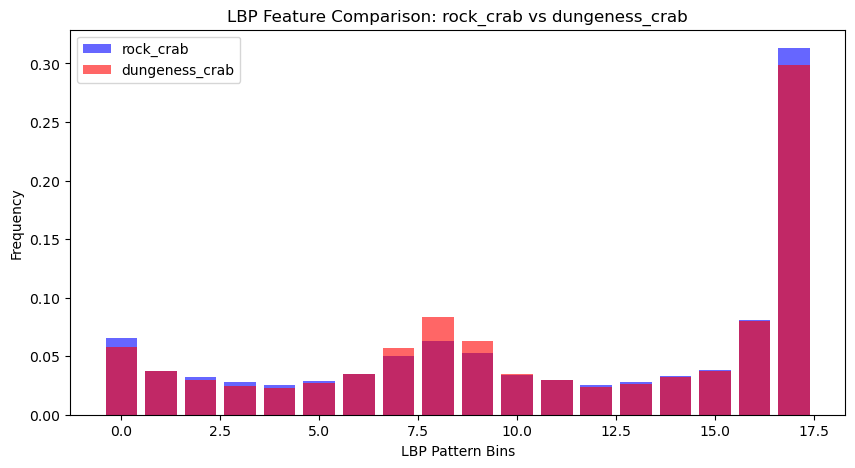

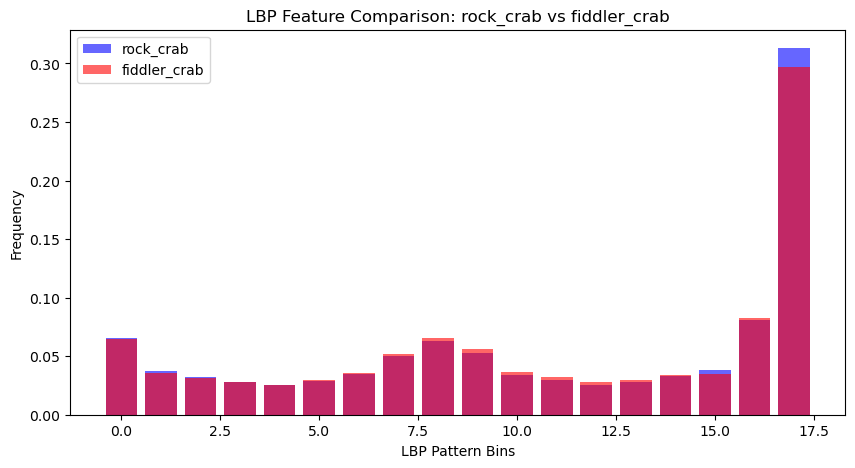

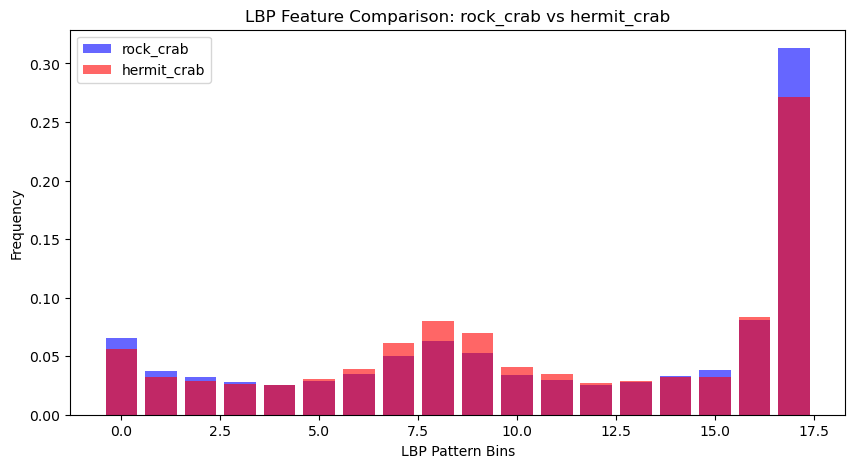

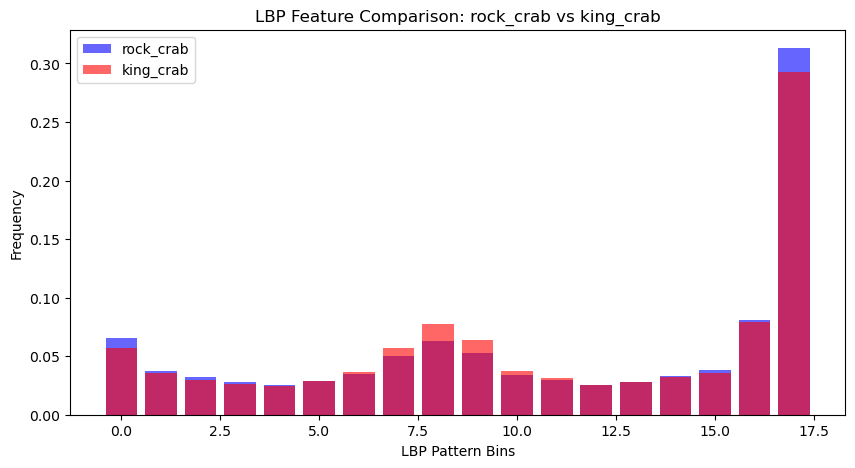

In [13]:
# Compare Rock Crab to other species
target =  "rock_crab"
species_list = ["dungeness_crab", "fiddler_crab", "hermit_crab", "king_crab"]

for species in species_list:
    cmpr_texture_feature_species(target, species)

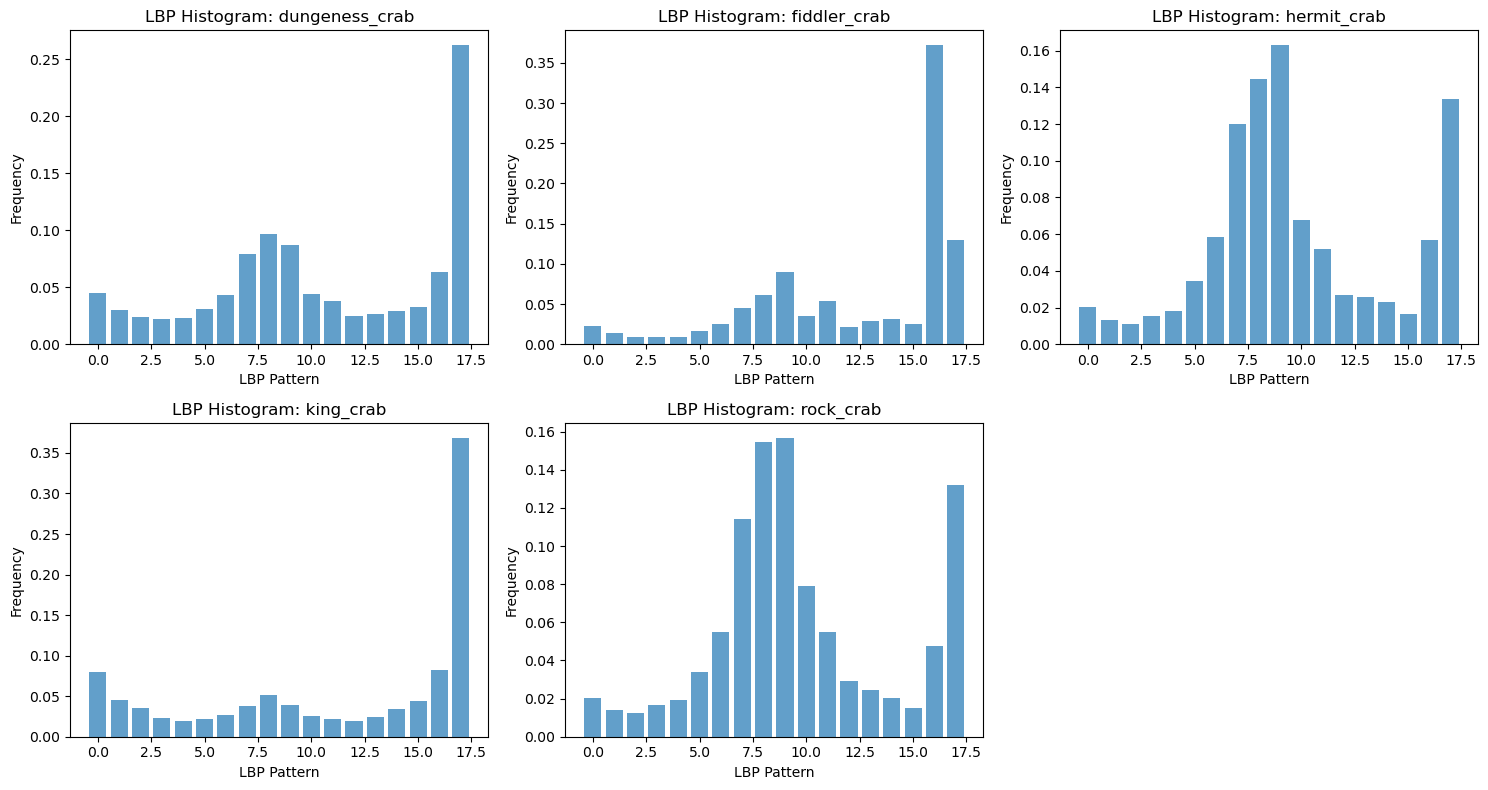

In [14]:
# Select random image from each species and display LBP histogram visualization
species_list = df["Species"].unique()
num_species = min(6, len(species_list))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, species in enumerate(species_list[:num_species]):
    species_data = df[df["Species"] == species].iloc[0, 1:].values
    
    ax = axes[i]
    ax.bar(range(len(species_data)), species_data, alpha=0.7)
    ax.set_title(f"LBP Histogram: {species}")
    ax.set_xlabel("LBP Pattern")
    ax.set_ylabel("Frequency")

# Remove unused subplot if species < 6
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the figure
plt.savefig("plot_LBP_hist.png")
plt.show()

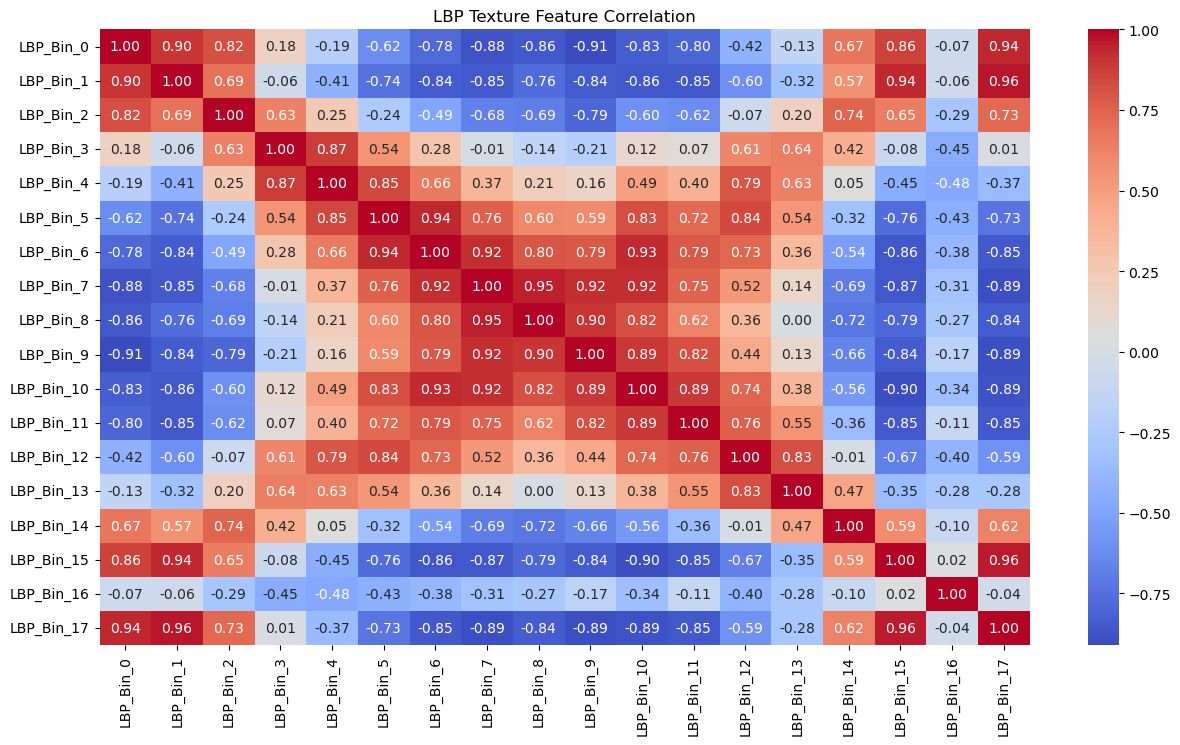

In [17]:
# Compute correlation matrix
correlation_matrix = df.drop(columns=["Species"]).corr()

# Display correlation using a heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("LBP Texture Feature Correlation")

# Save the figure
plt.savefig("plot_LBP_corr.png")
plt.show()